In [27]:
import sys
import pandas as pd
import xml.etree.ElementTree as ET
from pathlib import Path

ROOT = Path.cwd().parent.parent
if str(ROOT) not in sys.path:
    sys.path.append(str(ROOT))

import scripts.src.inputs.config as cfg
import matplotlib.pyplot as plt
import seaborn as sns

In [28]:
from collections import Counter
import re

log = "/media/fullsuper/ExternalDisk1/irene/sumo_run.log"
veh_teleport_count = Counter()
with open(log, encoding="utf-8", errors="ignore") as f:
    for line in f:
        if "Teleporting vehicle" in line:
            m = re.search(r"Teleporting vehicle '([^']+)'", line)
            if m:
                veh_teleport_count[m.group(1)] += 1

print("Veicoli teletrasportati più volte:")
for vid, count in veh_teleport_count.most_common(20):
    print(f"  {vid}: {count} volte")

Veicoli teletrasportati più volte:
  13183: 12 volte
  10696: 11 volte
  14106: 10 volte
  14118: 10 volte
  27820: 10 volte
  10205: 10 volte
  10368: 10 volte
  15560: 10 volte
  13182: 10 volte
  13013: 10 volte
  14325: 10 volte
  14979: 10 volte
  10327: 9 volte
  12962: 9 volte
  17870: 9 volte
  15585: 9 volte
  15604: 9 volte
  14671: 9 volte
  10716: 9 volte
  14275: 9 volte


In [30]:
import sumolib

net = sumolib.net.readNet(cfg.NET_FILE)

for street_base in ["1113770110", "1113770112", "1113770113", "1113770114",
                     "121952561", "154986388", "81240118", "81240119"]:
    edges = [e for e in net.getEdges() if e.getID().lstrip("-").split("#")[0] == street_base]
    for e in edges:
        print(f"{e.getID()}: numLanes={e.getLaneNumber()}, speed={e.getSpeed():.1f}, priority={e.getPriority()}")

1113770110#0: numLanes=3, speed=19.4, priority=8
1113770110#1: numLanes=3, speed=19.4, priority=8
1113770110#2: numLanes=3, speed=19.4, priority=8
1113770112#0: numLanes=3, speed=19.4, priority=8
1113770112#1: numLanes=3, speed=19.4, priority=8
1113770112#2: numLanes=3, speed=19.4, priority=8
1113770113#0: numLanes=3, speed=19.4, priority=8
1113770113#1: numLanes=3, speed=19.4, priority=8
1113770114#0: numLanes=4, speed=19.4, priority=8
1113770114#1: numLanes=4, speed=19.4, priority=8
1113770114#2: numLanes=4, speed=19.4, priority=8
1113770114#3: numLanes=4, speed=19.4, priority=8
121952561#0: numLanes=3, speed=19.4, priority=8
121952561#1: numLanes=3, speed=19.4, priority=8
121952561#2: numLanes=3, speed=19.4, priority=8
121952561#3: numLanes=3, speed=19.4, priority=8
154986388#0: numLanes=3, speed=19.4, priority=8
154986388#1: numLanes=3, speed=19.4, priority=8
154986388#2: numLanes=3, speed=19.4, priority=8
154986388#3: numLanes=3, speed=19.4, priority=8
81240118: numLanes=1, speed=

In [31]:
import xml.etree.ElementTree as ET

def select_route_element(veh):
    route_el = veh.find("route")
    if route_el is not None:
        return route_el
    route_dist = veh.find("routeDistribution")
    if route_dist is not None:
        routes = route_dist.findall("route")
        if not routes:
            return None
        if len(routes) == 1:
            return routes[0]
        def route_key(r):
            prob = float(r.get("probability", 0) or 0)
            cost = float(r.get("cost", "inf") or "inf")
            return (-prob, cost)
        return sorted(routes, key=route_key)[0]
    return None

tree = ET.parse("/media/fullsuper/ExternalDisk1/irene/dtSumo/scripts/output/marouter-workdir/MA_no_TLS_AM/marouter_output_clean.rou.xml")  # verifica sia il file giusto
root = tree.getroot()

top_level_routes = {
    r.get("id"): r.get("edges", "").split()
    for r in root.findall("route") if r.get("id") is not None
}

arterial_edges = {"1113770110#0","1113770110#1","1113770110#2","1113770112#0","1113770112#1","1113770112#2",
                   "1113770113#0","1113770113#1","1113770114#0","1113770114#1","1113770114#2","1113770114#3",
                   "121952561#0","121952561#1","121952561#2","121952561#3",
                   "154986388#0","154986388#1","154986388#2","154986388#3"}
funnel_edges = {"81240118", "81240119"}

count_via_arterial = 0
count_ending_residential = 0
n_total = 0
n_no_route = 0

for veh in root.findall("vehicle") + root.findall("trip"):
    n_total += 1
    route_el = select_route_element(veh)
    edges = None
    if route_el is not None:
        edges = route_el.get("edges", "").split()
    else:
        ref = veh.get("route")
        if ref in top_level_routes:
            edges = top_level_routes[ref]

    if not edges:
        n_no_route += 1
        continue

    if arterial_edges & set(edges):
        count_via_arterial += 1
        if edges[-1] in funnel_edges:
            count_ending_residential += 1

print(f"Veicoli totali nel file: {n_total}")
print(f"Veicoli senza route trovata: {n_no_route}")
print(f"Veicoli sull'arteria: {count_via_arterial}")
if count_via_arterial > 0:
    print(f"Di questi, con destinazione nell'imbuto: {count_ending_residential} "
          f"({count_ending_residential/count_via_arterial:.1%})")
else:
    print("Nessun veicolo trovato sull'arteria — controlla il file/gli id sotto")
    # stampa qualche route a campione per confronto manuale
    for veh in root.findall("vehicle")[:3]:
        route_el = select_route_element(veh)
        if route_el is not None:
            print(veh.get("id"), route_el.get("edges", "")[:200])

FileNotFoundError: [Errno 2] No such file or directory: '/media/fullsuper/ExternalDisk1/irene/dtSumo/scripts/output/marouter-workdir/MA_no_TLS_AM/marouter_output_clean.rou.xml'

In [32]:
import xml.etree.ElementTree as ET
tree = ET.parse("/media/fullsuper/ExternalDisk1/irene/dtSumo/scripts/output/marouter-workdir/MA_no_TLS_AM/marouter_output_extended.rou.xml")
root = tree.getroot()

n_single_alt = 0
n_multi_alt = 0
n_no_dist = 0

for veh in root.findall("vehicle") + root.findall("trip"):
    rd = veh.find("routeDistribution")
    if rd is None:
        if veh.find("route") is not None:
            n_no_dist += 1
        continue
    n_alt = len(rd.findall("route"))
    if n_alt <= 1:
        n_single_alt += 1
    else:
        n_multi_alt += 1

total = n_single_alt + n_multi_alt + n_no_dist
print(f"Veicoli totali con route: {total}")
print(f"Con 1 sola alternativa: {n_single_alt} ({n_single_alt/total:.1%})")
print(f"Con >1 alternative: {n_multi_alt} ({n_multi_alt/total:.1%})")
print(f"Senza routeDistribution (route diretta): {n_no_dist}")

Veicoli totali con route: 27603
Con 1 sola alternativa: 7815 (28.3%)
Con >1 alternative: 19788 (71.7%)
Senza routeDistribution (route diretta): 0


In [33]:
tripinfo_am  = Path("/media/fullsuper/ExternalDisk1/irene/dtSumo/scripts/output/simulation-out/out_MA_no_TLS/TripInfo_marouter_scaled1.0.xml")

tree = ET.parse(tripinfo_am)
root = tree.getroot()

info = []

for trip in root.findall("tripinfo"):
    info.append(
    {"id": float(trip.get("id")),
    "depart": float(trip.get("depart")),
    "departLane": str(trip.get("departLane")),
    "departPos": float(trip.get("departPos")),
    "arrival": float(trip.get("arrival")),
    "arrivalLane": str(trip.get("arrivalLane")),
    "arrivalPos": float(trip.get("arrivalPos")),
    "duration": float(trip.get("duration")),
    "routeLength": float(trip.get("routeLength")),
    "waitingTime": float(trip.get("waitingTime")),
    "timeLoss": float(trip.get("timeLoss")),
    })
    
df_res = pd.DataFrame(info)
df_res

,id,depart,departLane,departPos,arrival,arrivalLane,arrivalPos,duration,routeLength,waitingTime,timeLoss
0,1537.0,31.0,1167094068#0_0,0.0,36.0,134460789#9_0,43.72,5.0,48.32,0.0,0.00
1,48.0,45.0,1305781749_0,0.0,55.0,48998342#2_0,21.20,10.0,172.94,0.0,0.00
2,779.0,65.0,37679200#10_0,0.0,66.0,1307179610#0_0,0.20,1.0,2.22,0.0,0.00
3,913.0,23.0,678628384#5_0,0.0,76.0,134460789#10_0,49.45,53.0,742.44,0.0,0.00
4,545.0,57.0,1306068768#2_0,0.0,80.0,134572330#2_0,428.72,23.0,529.86,0.0,0.00
...,...,...,...,...,...,...,...,...,...,...,...
327026,331437.0,86376.0,1305446516#2_0,0.0,86395.0,677704594#1_0,89.60,19.0,318.54,0.0,0.00
327027,330160.0,86330.0,48998342#2_0,0.0,86396.0,-42212708#0_0,74.37,66.0,928.38,0.0,0.00
327028,331276.0,86379.0,397430750#2_0,0.0,86396.0,-840177719#1_0,127.55,17.0,167.42,0.0,0.00
327029,331519.0,86360.0,154986393#5_0,0.0,86398.0,-42212708#0_0,74.37,38.0,577.23,0.0,3.08


In [34]:
df = pd.DataFrame(info).sort_values("arrival", ascending=False)
print("Ultimi 20 veicoli ad arrivare:")
print(df.head(20)[["id", "depart", "duration", "routeLength"]])

Ultimi 20 veicoli ad arrivare:
              id   depart  duration  routeLength
327030  328915.0  86363.0      36.0       485.28
327029  331519.0  86360.0      38.0       577.23
327028  331276.0  86379.0      17.0       167.42
327027  330160.0  86330.0      66.0       928.38
327024  329235.0  86358.0      37.0       497.54
327026  331437.0  86376.0      19.0       318.54
327025  327257.0  86363.0      32.0       322.91
327023  326299.0  86387.0       6.0        93.18
327022  332272.0  86391.0       1.0         1.07
327020  327209.0  86374.0      17.0       265.31
327021  330831.0  86390.0       1.0         0.60
327019  327131.0  86289.0      99.0      1725.65
327018  326411.0  86374.0      13.0       270.05
327017  327488.0  86288.0      99.0      1316.77
327016  326737.0  86385.0       1.0         1.07
327015  326604.0  86306.0      80.0      1352.20
327013  328914.0  86348.0      37.0       485.28
327014  330421.0  86367.0      18.0       199.69
327012  329872.0  86300.0      85.0   

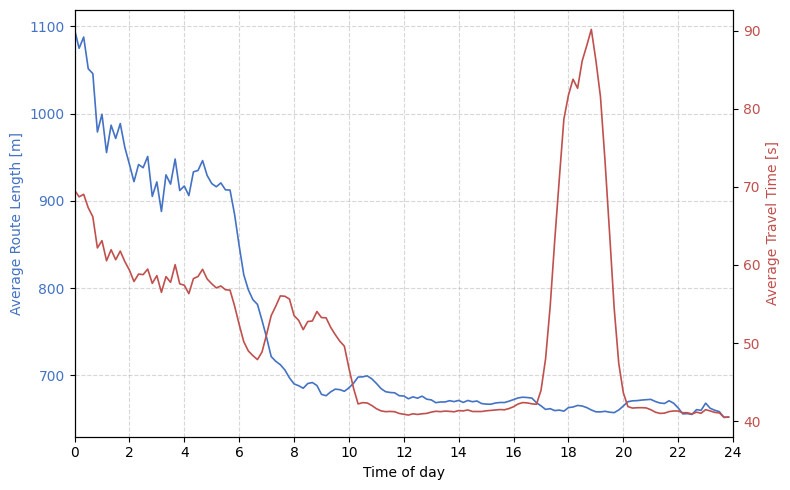

In [35]:
bin_size_min = 10
df_res["bin"] = (df_res["depart"] // (bin_size_min * 60)) * (bin_size_min * 60)

binned = df_res.groupby("bin").agg(
    avg_length=("routeLength", "mean"),
    avg_duration=("duration", "mean"),
).reset_index()
binned["hour"] = binned["bin"] / 3600.0

window = 3
binned["avg_length_smooth"] = binned["avg_length"].rolling(window, center=True, min_periods=1).mean()
binned["avg_duration_smooth"] = binned["avg_duration"].rolling(window, center=True, min_periods=1).mean()

fig, ax1 = plt.subplots(figsize=(8, 5))
ax2 = ax1.twinx()

ax1.plot(binned["hour"], binned["avg_length_smooth"], color="#4472C4", linewidth=1.2)
ax2.plot(binned["hour"], binned["avg_duration_smooth"], color="#C0504D", linewidth=1.2)

ax1.set_xlabel("Time of day")
ax1.set_ylabel("Average Route Length [m]", color="#4472C4")
ax2.set_ylabel("Average Travel Time [s]", color="#C0504D")
ax1.tick_params(axis="y", labelcolor="#4472C4")
ax2.tick_params(axis="y", labelcolor="#C0504D")

ax1.set_xlim(0, 24)
ax1.set_xticks(range(0, 25, 2))
ax1.grid(True, linestyle="--", alpha=0.5)

fig.tight_layout()
plt.savefig("route_length_vs_travel_time.png", dpi=150)
plt.show()

In [36]:
print(df_res['duration'].describe())
print(df_res['duration'].quantile([0.5, 0.9, 0.95, 0.99]))

count    327031.000000
mean         50.870321
std          83.829988
min           1.000000
25%          13.000000
50%          35.000000
75%          75.000000
max        2399.000000
Name: duration, dtype: float64
0.50     35.0
0.90    100.0
0.95    122.0
0.99    241.0
Name: duration, dtype: float64


In [18]:
tail99 = df_res[df_res["duration"] >= df_res["duration"].quantile(0.99)]
print(tail99[["id", "depart", "duration", "routeLength", "waitingTime"]].sort_values("duration", ascending=False).head(20))

            id   depart  duration  routeLength  waitingTime
52153  60643.0  29260.0     825.0      1777.08       238.63
54804  62960.0  29646.0     815.0      2551.61       209.64
56005  62964.0  29820.0     811.0      2551.61       252.68
53867  62957.0  29516.0     811.0      2551.61       307.57
53583  61627.0  29496.0     793.0      1826.38       257.34
56475  61672.0  29905.0     788.0      1826.38       251.98
56789  62967.0  29950.0     784.0      2551.61       163.05
54429  69265.0  29646.0     761.0      1153.31       209.71
56053  61669.0  29878.0     759.0      1855.34       176.40
55717  69277.0  29832.0     759.0      1153.71       154.16
55928  69279.0  29863.0     757.0      1153.71       149.89
56583  61677.0  29950.0     757.0      1826.38       148.63
52324  69246.0  29351.0     757.0      1153.71       244.52
51390  61596.0  29214.0     757.0      1826.38       130.08
56772  61680.0  29978.0     754.0      1826.38       215.96
56839  69287.0  29988.0     753.0      1

In [37]:
import geopandas as gpd
edges = ET.parse(cfg.EDG_PARSE_XML).getroot()

edges_data = {}

for e in edges.findall("edge"):
    if e.attrib.get("function") == "internal":
        continue
    eid = e.get("id")
    fid = e.get("from")
    tid = e.get("to")
    type_e = e.get("type")
    
    for lane in e.findall("lane"):
        lid = lane.get("id")
        lane_index = lane.attrib.get("index")
        length = lane.attrib.get("length")
        speed = lane.attrib.get("speed")
        l_shape = lane.attrib.get("shape")
        
        lane_data = {
            "id_edge": eid,
            "index": lane_index,
            "from": fid,
            "to": tid,
            "name": e.attrib.get("name", ""),
            "numLanes": e.attrib.get("numLanes", ""),
            "speed": speed,
            "length": length,
            "shape": l_shape,
        }

        # key = lane_id, value = lane_data
        edges_data[lid] = lane_data
        
df_lanes = pd.DataFrame.from_dict(edges_data, orient="index")
df_lanes

,id_edge,index,from,to,name,numLanes,speed,length,shape
-104183437_0,-104183437,0,2939596349,1202156217,,1,8.33,18.37,"7.623217640335089,45.06872643196363 7.62299753..."
-104183444_0,-104183444,0,1202156207,1202156215,,1,8.33,23.25,"7.623302990639859,45.06856830884287 7.62302589..."
-104183448_0,-104183448,0,1202156188,1202156183,,1,8.33,12.43,"7.623143696786155,45.06886974953819 7.62299469..."
-1062120746_0,-1062120746,0,9757569402,9757569401,,1,8.33,21.56,"7.614825673615891,45.06806070418173 7.61508745..."
-106837756_0,-106837756,0,943583045,1228515532,Via Chambery,1,13.89,88.77,"7.615166861007469,45.06895017167228 7.61523946..."
...,...,...,...,...,...,...,...,...,...
952537916#1_0,952537916#1,0,8816346176,8816346175,,1,8.33,23.45,"7.632929026250044,45.07311663538644 7.63294093..."
952537916#2_0,952537916#2,0,8816346175,8816346171,,1,8.33,28.96,"7.633132621479613,45.07299088687306 7.63315283..."
99754717#0_0,99754717#0,0,1153150681,1153150653,Via Onorato Castellino,1,13.89,87.87,"7.63195602791404,45.06977286982974 7.631733851..."
99754717#1_0,99754717#1,0,1153150653,1153150688,Via Onorato Castellino,1,13.89,143.4,"7.631429941346878,45.06893371731799 7.63092902..."


In [38]:
usage_depart = df_res.groupby("departLane").size().rename("n_inserted").reset_index()
usage_arrival = df_res.groupby("arrivalLane").size().rename("n_inserted").reset_index()
usage_depart

,departLane,n_inserted
0,-1062120746_0,5
1,-110531712#0_0,14
2,-110531712#1_0,14
3,-110531715_0,14
4,-110531716#0_0,15
...,...,...
1716,952537916#1_0,15
1717,952537916#2_0,15
1718,99754717#0_0,15
1719,99754717#1_0,15


In [39]:
from shapely import LineString

df_lanes['geometry'] = df_lanes["shape"].apply(
        lambda shape: LineString(
                [tuple(map(float, coord.split(","))) for coord in shape.split()]
        )
)

gdf_lanes = gpd.GeoDataFrame(df_lanes, geometry="geometry", crs="EPSG:32632")
gdf_lanes = gdf_lanes.reset_index().rename(columns={"level_0": "lane_id"})

gdf_lanes

,lane_id,id_edge,index,from,to,name,numLanes,speed,length,shape,geometry
0,-104183437_0,-104183437,0,2939596349,1202156217,,1,8.33,18.37,"7.623217640335089,45.06872643196363 7.62299753...","LINESTRING (7.623 45.069, 7.623 45.069)"
1,-104183444_0,-104183444,0,1202156207,1202156215,,1,8.33,23.25,"7.623302990639859,45.06856830884287 7.62302589...","LINESTRING (7.623 45.069, 7.623 45.068)"
2,-104183448_0,-104183448,0,1202156188,1202156183,,1,8.33,12.43,"7.623143696786155,45.06886974953819 7.62299469...","LINESTRING (7.623 45.069, 7.623 45.069)"
3,-1062120746_0,-1062120746,0,9757569402,9757569401,,1,8.33,21.56,"7.614825673615891,45.06806070418173 7.61508745...","LINESTRING (7.615 45.068, 7.615 45.068)"
4,-106837756_0,-106837756,0,943583045,1228515532,Via Chambery,1,13.89,88.77,"7.615166861007469,45.06895017167228 7.61523946...","LINESTRING (7.615 45.069, 7.615 45.068)"
...,...,...,...,...,...,...,...,...,...,...,...
3485,952537916#1_0,952537916#1,0,8816346176,8816346175,,1,8.33,23.45,"7.632929026250044,45.07311663538644 7.63294093...","LINESTRING (7.633 45.073, 7.633 45.073, 7.633 ..."
3486,952537916#2_0,952537916#2,0,8816346175,8816346171,,1,8.33,28.96,"7.633132621479613,45.07299088687306 7.63315283...","LINESTRING (7.633 45.073, 7.633 45.073, 7.633 ..."
3487,99754717#0_0,99754717#0,0,1153150681,1153150653,Via Onorato Castellino,1,13.89,87.87,"7.63195602791404,45.06977286982974 7.631733851...","LINESTRING (7.632 45.07, 7.632 45.069, 7.632 4..."
3488,99754717#1_0,99754717#1,0,1153150653,1153150688,Via Onorato Castellino,1,13.89,143.4,"7.631429941346878,45.06893371731799 7.63092902...","LINESTRING (7.631 45.069, 7.631 45.068, 7.631 ..."


In [40]:
gdf_usage_depart = gdf_lanes.merge(usage_depart, left_on="lane_id", right_on="departLane", how="left")
gdf_usage_depart["n_inserted"] = gdf_usage_depart["n_inserted"].fillna(0)

gdf_usage_depart

,lane_id,id_edge,index,from,to,name,numLanes,speed,length,shape,geometry,departLane,n_inserted
0,-104183437_0,-104183437,0,2939596349,1202156217,,1,8.33,18.37,"7.623217640335089,45.06872643196363 7.62299753...","LINESTRING (7.623 45.069, 7.623 45.069)",NaN,0.0
1,-104183444_0,-104183444,0,1202156207,1202156215,,1,8.33,23.25,"7.623302990639859,45.06856830884287 7.62302589...","LINESTRING (7.623 45.069, 7.623 45.068)",NaN,0.0
2,-104183448_0,-104183448,0,1202156188,1202156183,,1,8.33,12.43,"7.623143696786155,45.06886974953819 7.62299469...","LINESTRING (7.623 45.069, 7.623 45.069)",NaN,0.0
3,-1062120746_0,-1062120746,0,9757569402,9757569401,,1,8.33,21.56,"7.614825673615891,45.06806070418173 7.61508745...","LINESTRING (7.615 45.068, 7.615 45.068)",-1062120746_0,5.0
4,-106837756_0,-106837756,0,943583045,1228515532,Via Chambery,1,13.89,88.77,"7.615166861007469,45.06895017167228 7.61523946...","LINESTRING (7.615 45.069, 7.615 45.068)",NaN,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3485,952537916#1_0,952537916#1,0,8816346176,8816346175,,1,8.33,23.45,"7.632929026250044,45.07311663538644 7.63294093...","LINESTRING (7.633 45.073, 7.633 45.073, 7.633 ...",952537916#1_0,15.0
3486,952537916#2_0,952537916#2,0,8816346175,8816346171,,1,8.33,28.96,"7.633132621479613,45.07299088687306 7.63315283...","LINESTRING (7.633 45.073, 7.633 45.073, 7.633 ...",952537916#2_0,15.0
3487,99754717#0_0,99754717#0,0,1153150681,1153150653,Via Onorato Castellino,1,13.89,87.87,"7.63195602791404,45.06977286982974 7.631733851...","LINESTRING (7.632 45.07, 7.632 45.069, 7.632 4...",99754717#0_0,15.0
3488,99754717#1_0,99754717#1,0,1153150653,1153150688,Via Onorato Castellino,1,13.89,143.4,"7.631429941346878,45.06893371731799 7.63092902...","LINESTRING (7.631 45.069, 7.631 45.068, 7.631 ...",99754717#1_0,15.0


In [41]:
gdf_usage_arrival = gdf_lanes.merge(usage_arrival, left_on="lane_id", right_on="arrivalLane", how="left")
gdf_usage_arrival["n_inserted"] = gdf_usage_arrival["n_inserted"].fillna(0)

gdf_usage_arrival

,lane_id,id_edge,index,from,to,name,numLanes,speed,length,shape,geometry,arrivalLane,n_inserted
0,-104183437_0,-104183437,0,2939596349,1202156217,,1,8.33,18.37,"7.623217640335089,45.06872643196363 7.62299753...","LINESTRING (7.623 45.069, 7.623 45.069)",-104183437_0,3.0
1,-104183444_0,-104183444,0,1202156207,1202156215,,1,8.33,23.25,"7.623302990639859,45.06856830884287 7.62302589...","LINESTRING (7.623 45.069, 7.623 45.068)",NaN,0.0
2,-104183448_0,-104183448,0,1202156188,1202156183,,1,8.33,12.43,"7.623143696786155,45.06886974953819 7.62299469...","LINESTRING (7.623 45.069, 7.623 45.069)",-104183448_0,2.0
3,-1062120746_0,-1062120746,0,9757569402,9757569401,,1,8.33,21.56,"7.614825673615891,45.06806070418173 7.61508745...","LINESTRING (7.615 45.068, 7.615 45.068)",-1062120746_0,10.0
4,-106837756_0,-106837756,0,943583045,1228515532,Via Chambery,1,13.89,88.77,"7.615166861007469,45.06895017167228 7.61523946...","LINESTRING (7.615 45.069, 7.615 45.068)",NaN,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3485,952537916#1_0,952537916#1,0,8816346176,8816346175,,1,8.33,23.45,"7.632929026250044,45.07311663538644 7.63294093...","LINESTRING (7.633 45.073, 7.633 45.073, 7.633 ...",NaN,0.0
3486,952537916#2_0,952537916#2,0,8816346175,8816346171,,1,8.33,28.96,"7.633132621479613,45.07299088687306 7.63315283...","LINESTRING (7.633 45.073, 7.633 45.073, 7.633 ...",NaN,0.0
3487,99754717#0_0,99754717#0,0,1153150681,1153150653,Via Onorato Castellino,1,13.89,87.87,"7.63195602791404,45.06977286982974 7.631733851...","LINESTRING (7.632 45.07, 7.632 45.069, 7.632 4...",NaN,0.0
3488,99754717#1_0,99754717#1,0,1153150653,1153150688,Via Onorato Castellino,1,13.89,143.4,"7.631429941346878,45.06893371731799 7.63092902...","LINESTRING (7.631 45.069, 7.631 45.068, 7.631 ...",NaN,0.0


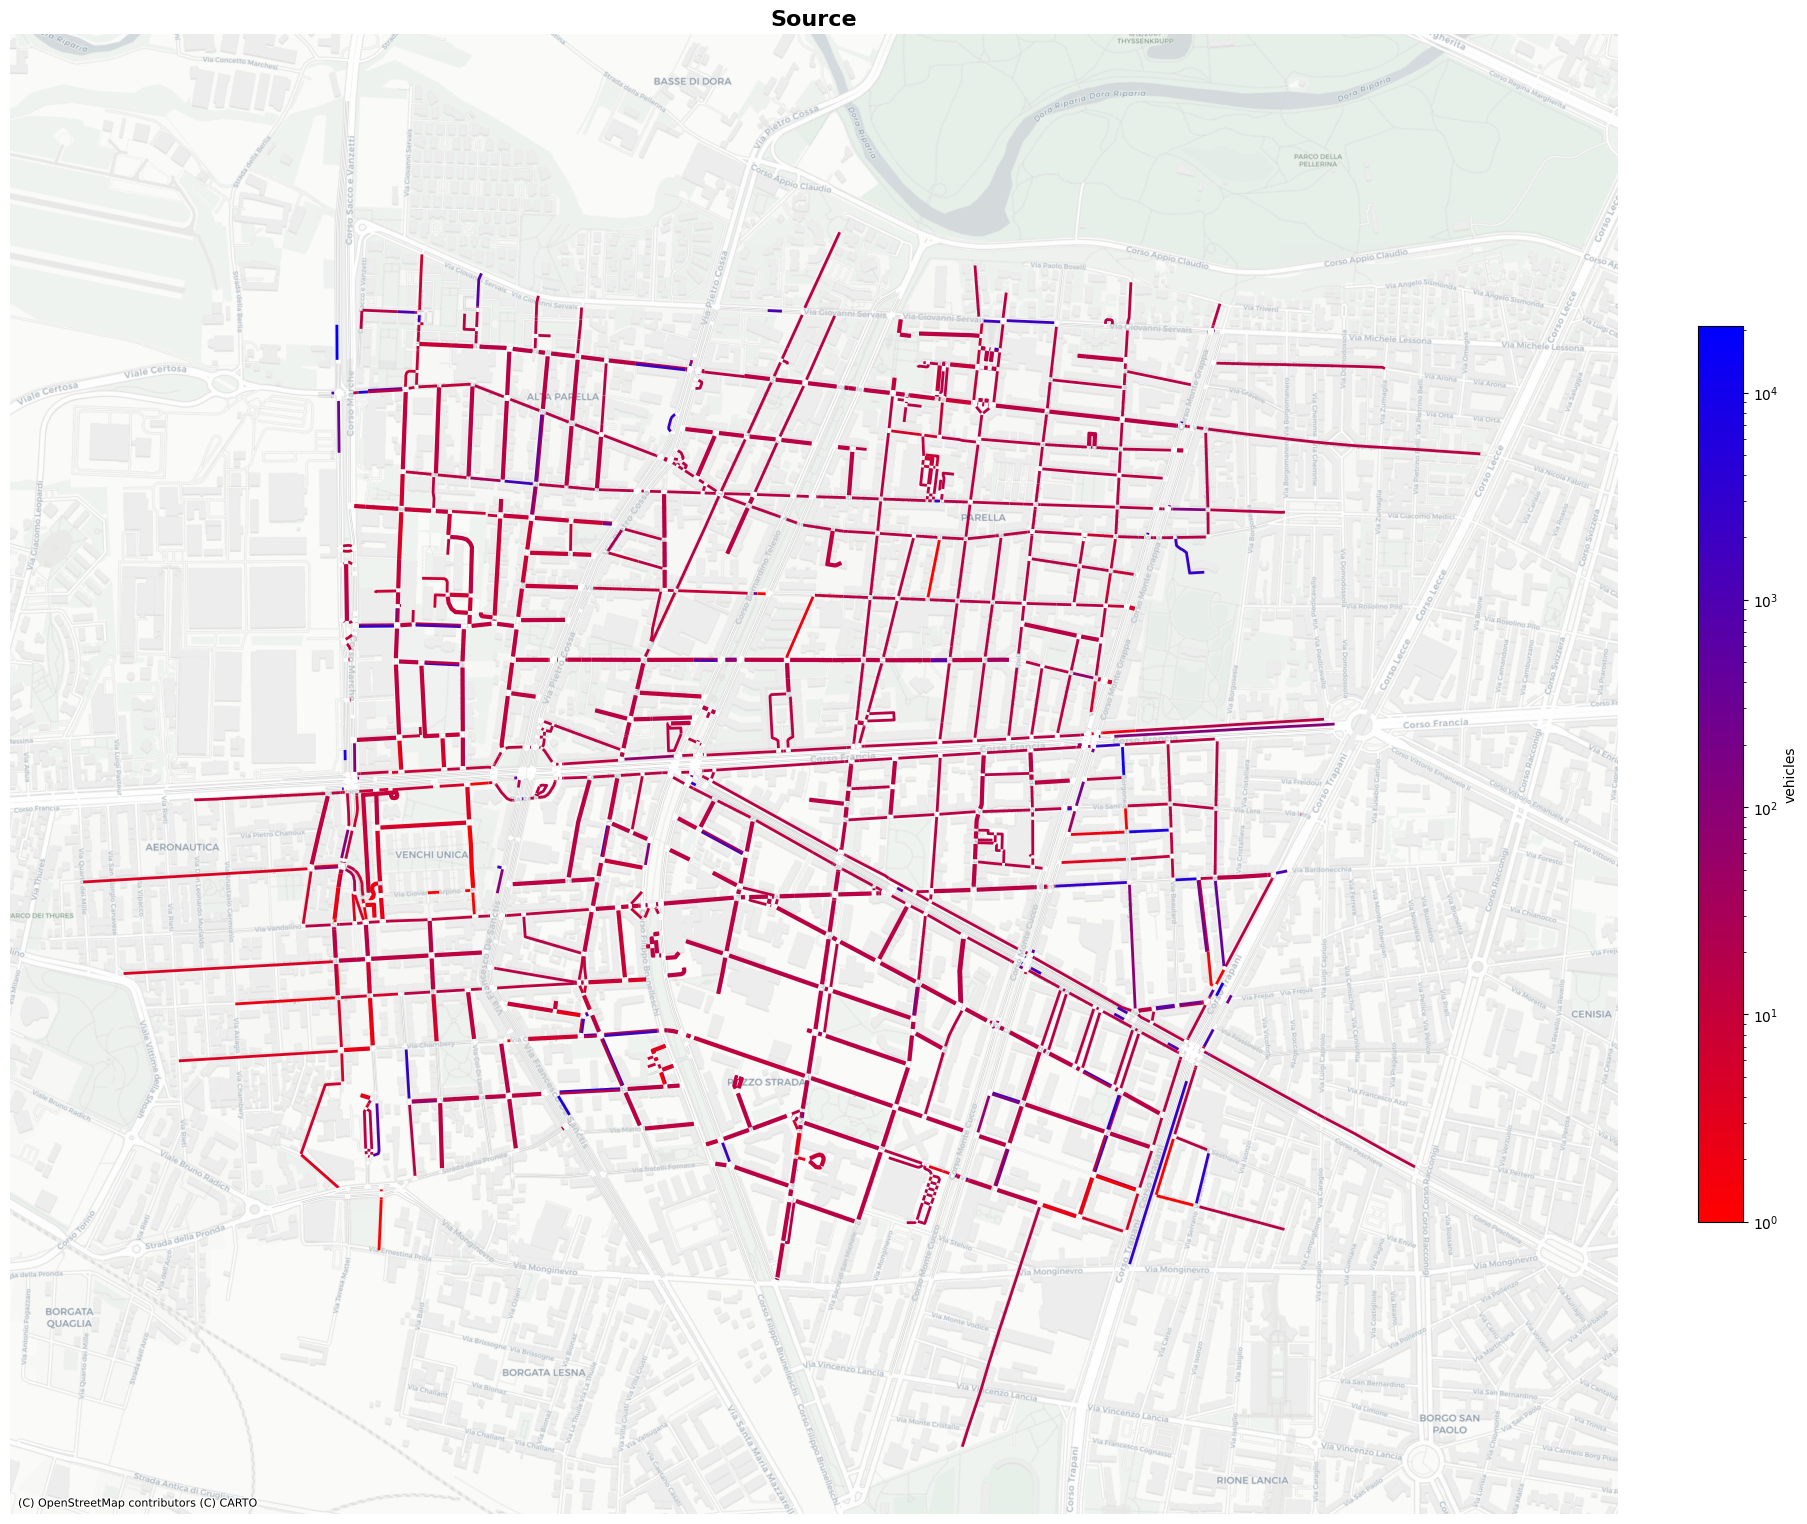

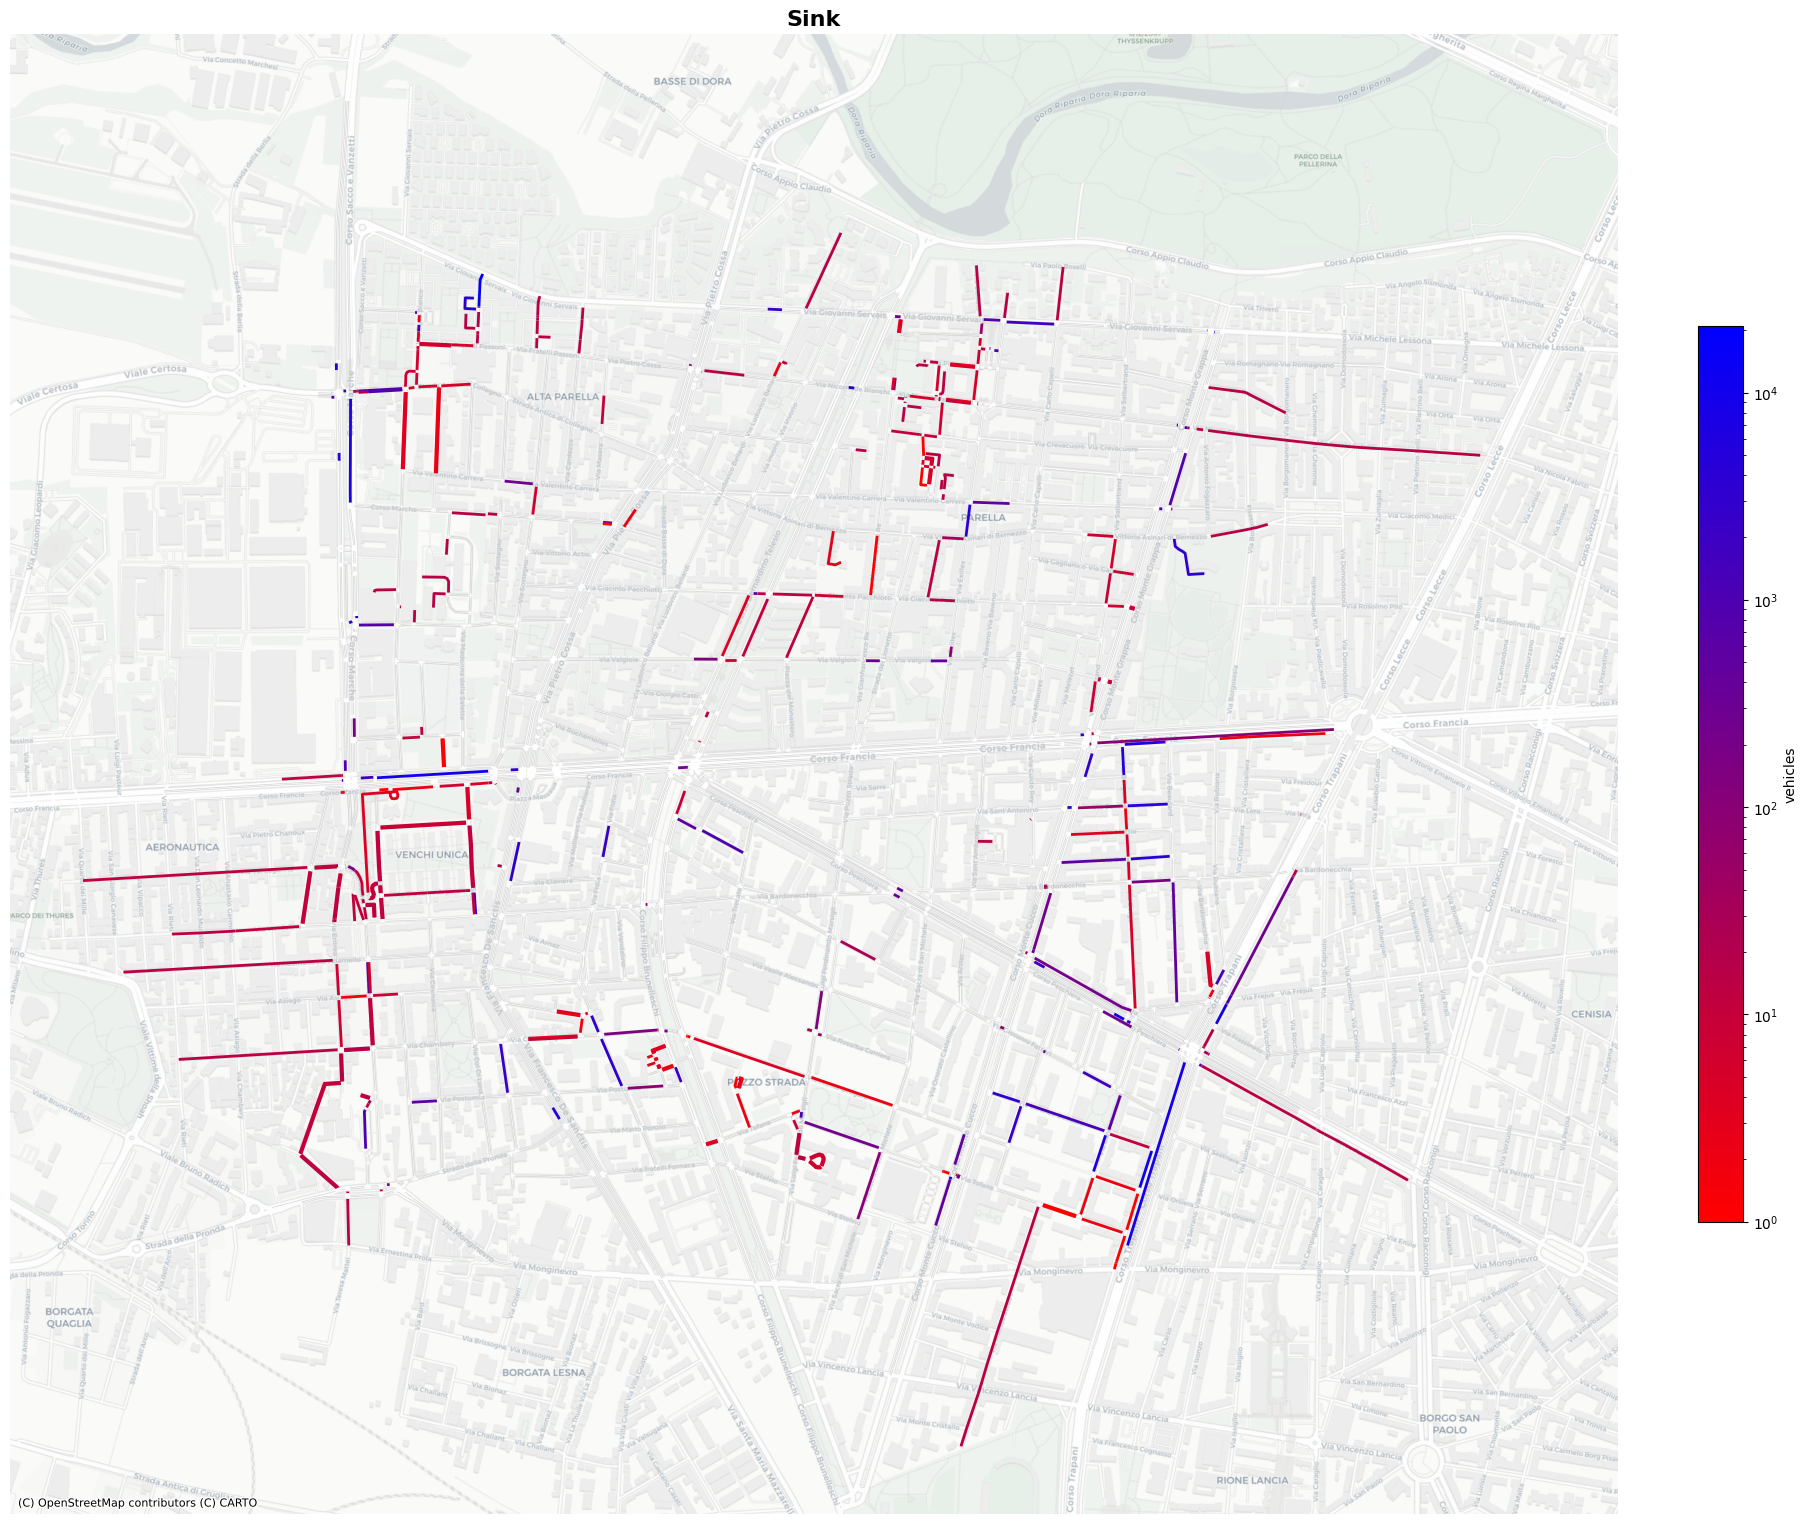

In [42]:
import matplotlib.colors as mcolors
import contextily as cx

gdf_lanes.crs = "EPSG:4326"
gdf_usage_depart.crs = "EPSG:4326"
gdf_usage_arrival.crs = "EPSG:4326"

gdf_lanes_3857 = gdf_lanes.to_crs(epsg=3857)
gdf_usage_depart_3857 = gdf_usage_depart.to_crs(epsg=3857)
gdf_usage_arrival_3857 = gdf_usage_arrival.to_crs(epsg=3857)


vmax = max(gdf_usage_depart["n_inserted"].max(), gdf_usage_arrival["n_inserted"].max())
vmin = 0

for gdf, title in zip(
        [gdf_usage_depart_3857, gdf_usage_arrival_3857], ["Source", "Sink"]
):
        fig, ax = plt.subplots(figsize=(18, 18), constrained_layout=True)
        gdf_lanes_3857.plot(ax=ax, color="lightgrey", linewidth=0.5, zorder=1)
        norm = mcolors.LogNorm(vmin=1, vmax=vmax)

        used = gdf[gdf["n_inserted"] > 0]
        used.plot(
                ax=ax,
                column="n_inserted",
                cmap=sns.blend_palette(["red", "blue"], as_cmap=True),
                norm=norm,
                linewidth=2,
                legend=True,
                zorder=2,
                legend_kwds={"label": "vehicles", "shrink": 0.5},
        )
        cx.add_basemap(
                ax=ax, source=cx.providers.CartoDB.Positron, zoom=16, zorder=0
        )
        ax.set_title(title, fontsize=16, fontweight="bold")
        ax.set_axis_off()
        ax.set_aspect("equal")

Text(0.5, 1.0, 'TimeLoss per ora di partenza')

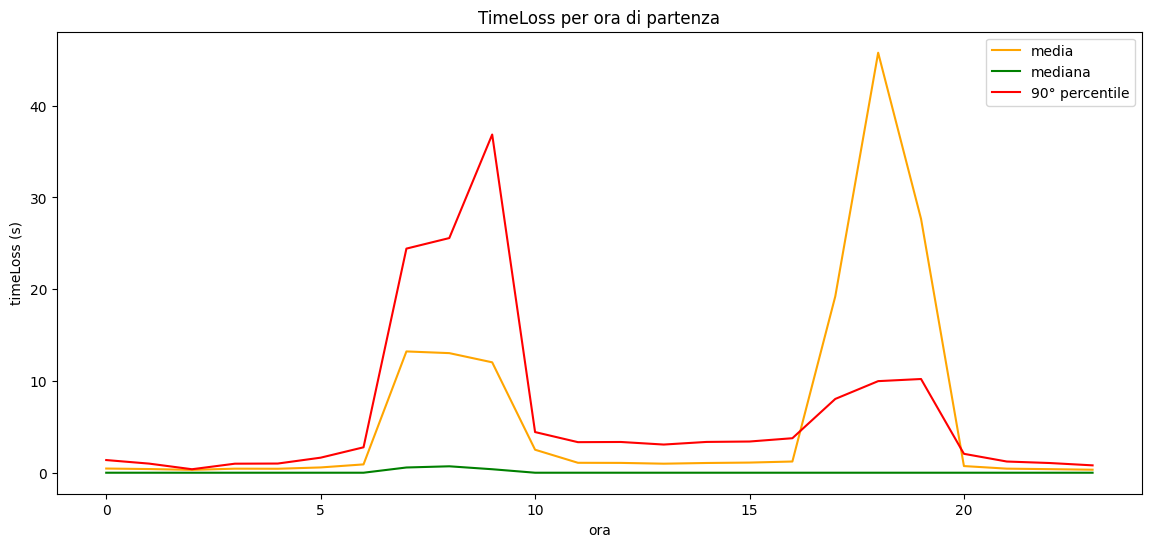

In [43]:
fig, ax1 = plt.subplots(figsize=(14, 6))
df_res["hour"] = (df_res["depart"] // 3600).astype(int)
stats = df_res.groupby("hour")["timeLoss"].agg(["mean", "median", lambda x: x.quantile(0.9)])
stats.columns = ["mean", "median", "p90"]

ax1.plot(stats.index, stats["mean"], label="media", color="orange")
ax1.plot(stats.index, stats["median"], label="mediana", color="green")
ax1.plot(stats.index, stats["p90"], label="90° percentile", color="red")
ax1.set_xlabel("ora")
ax1.set_ylabel("timeLoss (s)")
ax1.legend()
ax1.set_title("TimeLoss per ora di partenza")